In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

In [2]:
pd.set_option('display.max_columns', None)
X_train = pd.read_csv('data/train05_no_apache.csv')
y_train = pd.read_csv('data/Ytrain05.csv').squeeze()
X_test = pd.read_csv('data/test_no_apache.csv').squeeze()
y_test = pd.read_csv('data/y_test.csv').squeeze()
X_train.head(5)

,age,elective_surgery,gender,height,pre_icu_los_days,weight,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,d1_heartrate_range,d1_mbp_range,d1_resprate_range,d1_spo2_range,d1_sysbp_range,d1_temp_range,h1_diasbp_range,h1_heartrate_range,h1_mbp_range,h1_resprate_range,h1_spo2_range,h1_sysbp_range,h1_temp_range,d1_albumin_range,d1_bilirubin_range,d1_bun_range,d1_calcium_range,d1_creatinine_range,d1_glucose_range,d1_hco3_range,d1_hemaglobin_range,d1_platelets_range,d1_potassium_range,d1_sodium_range,d1_wbc_range,h1_glucose_range
0,76.0,0.0,0.0,163.0,0.000000,74.1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,16.0,57.0,14.0,13.0,83.0,0.7,11.0,8.0,11.0,5.0,3.0,15.0,0.1,0.0,0.1,13.0,0.3,1.10,210.0,1.0,0.8,22.0,0.1,1.0,0.85,0.0
1,79.0,0.0,0.0,168.5,0.078472,71.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,47.0,51.0,6.0,11.0,67.0,0.3,6.0,4.0,5.0,0.0,4.0,20.0,0.0,0.1,0.1,1.0,0.8,0.10,24.0,5.0,0.0,0.0,0.8,2.0,0.00,6.0
2,55.0,0.0,0.0,162.6,0.000000,102.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,30.0,24.0,9.0,11.0,49.0,0.4,7.0,7.0,0.0,3.0,1.0,21.0,0.0,0.0,0.0,2.0,0.2,0.10,6.0,2.0,1.1,4.0,0.2,0.0,3.90,0.0
3,44.0,1.0,0.0,157.4,0.194444,59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29.0,8.0,13.0,7.0,13.0,3.8,0.0,17.0,0.0,8.0,0.0,0.0,0.2,0.0,0.1,2.0,0.1,0.01,41.0,0.0,0.0,22.0,0.6,12.0,3.30,5.0
4,28.0,1.0,0.0,175.0,1.197917,64.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,34.0,22.0,11.0,3.0,17.0,1.0,12.0,17.0,8.0,3.0,3.0,12.0,0.0,0.1,0.1,0.0,0.0,0.00,47.0,0.0,0.2,0.0,0.0,0.0,0.00,0.0


In [3]:
params = {'max_features': ['sqrt', 'log2'],
          'n_estimators': [300, 400, 500],
          'max_depth': [10, 20, 30, 40],
          'min_samples_split': [5, 10, 20, 30]
          }

rf = RandomForestClassifier(random_state = 24)

fold = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 24)

search = RandomizedSearchCV(
    estimator = rf,
    param_distributions = params,
    n_iter = 70,
    scoring = 'f1',
    cv = fold,
    verbose = 2,
    n_jobs = -1,
    random_state = 24
)

search.fit(X_train, y_train)

y_proba = search.predict_proba(X_test)[:,1]
y_pred = search.predict(X_test)

Fitting 5 folds for each of 70 candidates, totalling 350 fits
[CV] END max_depth=20, max_features=log2, min_samples_split=5, n_estimators=400; total time=  42.8s
[CV] END max_depth=20, max_features=log2, min_samples_split=5, n_estimators=400; total time=  44.5s
[CV] END max_depth=20, max_features=log2, min_samples_split=5, n_estimators=400; total time=  44.7s
[CV] END max_depth=20, max_features=log2, min_samples_split=5, n_estimators=400; total time=  44.1s
[CV] END max_depth=20, max_features=log2, min_samples_split=5, n_estimators=400; total time=  44.1s
[CV] END max_depth=40, max_features=log2, min_samples_split=5, n_estimators=500; total time= 1.1min
[CV] END max_depth=40, max_features=log2, min_samples_split=5, n_estimators=500; total time= 1.1min
[CV] END max_depth=40, max_features=log2, min_samples_split=5, n_estimators=500; total time= 1.0min
[CV] END max_depth=40, max_features=log2, min_samples_split=5, n_estimators=500; total time= 1.0min
[CV] END max_depth=40, max_features=lo

In [4]:
print(search.best_params_)

{'n_estimators': 400, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 40}


Accuracy: 91.66%
Recall: 9.05%
Precision: 69.69%
F1: 16.03%


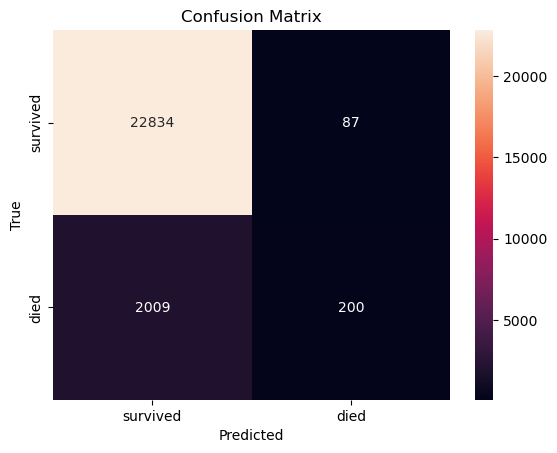

In [5]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f%%' % (accuracy * 100.0))
print('Recall: %.2f%%' % (recall * 100.0))
print('Precision: %.2f%%' % (precision * 100.0))
print('F1: %.2f%%' % (f1 * 100.0))

matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');
ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']);
ax.yaxis.set_ticklabels(['survived', 'died']);

In [6]:
matrix

array([[22834,    87],
       [ 2009,   200]])

AUC: 0.8200294281404968


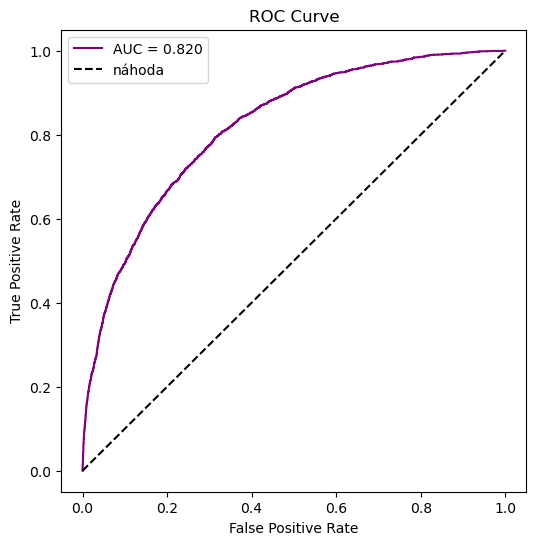

In [7]:
auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color = 'purple')
plt.plot([0,1], [0,1], 'k--', label='náhoda')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [9]:
fold = StratifiedKFold(n_splits =  5, shuffle = True, random_state = 24)

oof_proba = np.zeros(len(X_train))
oof_y = y_train.values 

best_model = rf

for train_idx, val_idx in fold.split(X_train, y_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = clone(best_model)
    
    model.fit(X_tr, y_tr)
    
    oof_proba[val_idx] = model.predict_proba(X_val)[:, 1]

In [10]:
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

best_t = 0
best_score = 0

for t in thresholds:
    y_pred = (oof_proba >= t).astype(int)
    recall = recall_score(oof_y, y_pred)
    precision = precision_score(oof_y, y_pred)
    f1 = f1_score(oof_y, y_pred)
    
    print(
        t,
        'bincount:', np.bincount(y_pred),
        'unique:', np.unique(y_pred),
        'recall:', recall,
        'precision:', precision,
        'f1:', f1
        
    )
    
    score = 0.7 * recall + 0.3* precision

    if score > best_score:
        best_score = score
        best_t = t

print('Best threshold:', best_t)
print('Best score:', best_score)

0.4 bincount: [52188 28035] unique: [0 1] recall: 0.990875434725702 precision: 0.9451400035669698 f1: 0.9674675040163575
0.45 bincount: [52839 27384] unique: [0 1] recall: 0.9902771025765679 precision: 0.9670245398773006 f1: 0.9785127020785219
0.5 bincount: [53257 26966] unique: [0 1] recall: 0.9894170001121873 precision: 0.9811614625825114 f1: 0.9852719384810174
0.55 bincount: [53509 26714] unique: [0 1] recall: 0.9885942934071277 precision: 0.9895934715879314 f1: 0.9890936301562061
0.6 bincount: [53678 26545] unique: [0 1] recall: 0.9873976291088591 precision: 0.9946882652100207 f1: 0.9910295387156101
Best threshold: 0.6
Best score: 0.9895848199392074


In [11]:
y_pred_test = (y_proba >= best_t).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     22921
           1       0.73      0.02      0.05      2209

    accuracy                           0.91     25130
   macro avg       0.82      0.51      0.50     25130
weighted avg       0.90      0.91      0.87     25130



Accuracy: 91.35%
Recall: 2.49%
Precision: 73.33%
F1: 4.82%


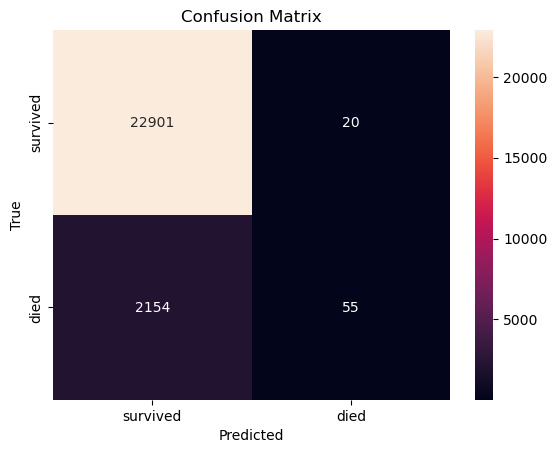

In [12]:
accuracy = accuracy_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print('Accuracy: %.2f%%' % (accuracy * 100.0))
print('Recall: %.2f%%' % (recall * 100.0))
print('Precision: %.2f%%' % (precision * 100.0))
print('F1: %.2f%%' % (f1 * 100.0))

matrix = confusion_matrix(y_test, y_pred_test)
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');
ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']); ax.yaxis.set_ticklabels(['survived', 'died']);

In [13]:
matrix

array([[22901,    20],
       [ 2154,    55]])